# Hands-on AI in Healthcare - Chapter 3: Classical Statistics for Population Health

## 3.1 Setting Up Your Workbench

In this section, we'll confirm that your Python environment is working by loading a real
public health dataset and creating a simple visualization. By the end of this notebook,
you'll have downloaded county-level health data from the County Health Rankings & Roadmaps
project and produced a scatter plot showing how diabetes prevalence relates to household
income across counties in California.

Here's where we're headed: imagine you work at the California Department of Health and
your director has asked, "Which counties should we prioritize for diabetes prevention
funding, and how much difference could an obesity-reduction program actually make?" By
the end of this chapter, you'll have the statistical tools to answer both questions with
real data. Every technique we learn along the way — regression, model evaluation, gradient
descent — builds toward that practical goal.

If this notebook runs without errors, your workbench is ready for the rest of the chapter.

### Installing and Importing Libraries

We'll use three libraries throughout this book:

- **pandas** — for loading and manipulating tabular data
- **matplotlib** — for creating charts and visualizations
- **scikit-learn** — for building statistical models (we won't use this yet, but let's
  confirm it's installed)

Run the cell below to install them. If they're already installed, pip will simply report
that the requirement is satisfied.

In [ ]:
# Install the libraries we'll use throughout the book.
# You only need to run this cell once per environment.
%pip install pandas matplotlib scikit-learn numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print("\nAll libraries loaded successfully!")

pandas     : 3.0.1
numpy      : 2.4.4
matplotlib : 3.10.8
scikit-learn: 1.8.0

All libraries loaded successfully!


### About the Data

The [County Health Rankings & Roadmaps](https://www.countyhealthrankings.org/) project,
a collaboration between the Robert Wood Johnson Foundation and the University of Wisconsin
Population Health Institute, publishes annual county-level health data for every county in
the United States. The dataset includes dozens of measures covering health outcomes, health
behaviors, clinical care, social and economic factors, and the physical environment.

We'll use several measures from this dataset throughout the chapter. The two we start with
are:

- **Diabetes prevalence** — the percentage of adults aged 20 and older with diagnosed diabetes
- **Median household income** — the income level at which half of households earn more
  and half earn less

The data is freely available and requires no login or account to download.

### Downloading the Data

The County Health Rankings publishes its national analytic dataset as a CSV file each year.
Before we can load it, you'll need to download it manually:

1. Visit the County Health Rankings data documentation page at
   [countyhealthrankings.org/health-data/methodology-and-sources/data-documentation](https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation)
2. Find the **National Data** section and download the **analytic data** CSV file
   (the filename will look something like `analytic_data2024.csv`)
3. Place the downloaded file in a folder called `working` next to this notebook

Your file structure should look like this:

```
chapter_3.ipynb
working/
    analytic_data2024.csv
```

The CSV file has a two-row header: the first row contains human-readable descriptions,
and the second row contains computer-friendly variable codes (like `v060_rawvalue`).
We'll use the variable codes as our column names and skip the description row.

In [3]:
import glob

# Look for the analytic data CSV in the working/ folder.
# This pattern matches any file starting with "analytic_data" so it will
# work regardless of which year's file you downloaded.
csv_files = sorted(glob.glob("working/analytic_data*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No analytic_data*.csv file found in the working/ folder.\n"
        "Please download the file from countyhealthrankings.org and place it "
        "in a folder called 'working' next to this notebook."
    )

csv_path = csv_files[-1]  # Use the most recent file if multiple are present
print(f"Loading: {csv_path}")

# Read the CSV.
# Row 1, the second row, has computer-friendly variable names (our column names);
# row 0, or the first row, has descriptions that we skip.
# Using encoding="latin-1" handles special characters that occasionally appear in county names.
chr_data = pd.read_csv(
    csv_path,
    header=0,
    skiprows=[0],
    encoding="latin-1",
)

print(f"Dataset shape: {chr_data.shape[0]:,} rows × {chr_data.shape[1]} columns")

Loading: working/analytic_data2024.csv
Dataset shape: 3,195 rows × 770 columns


### [BONUS] Exploring the Data

Before we do anything else, let's look at what we downloaded. This is a habit worth
building — always inspect your data before analyzing it. Even a quick glance can
reveal missing values, unexpected formats, or columns with names you didn't expect.

In [ ]:
# Show the first few rows to get a feel for the data.
chr_data.head()

In [ ]:
# List all column names. This is especially useful with large datasets
# where .head() truncates the display.
print("Number of columns:", len(chr_data.columns))
print()
for col in chr_data.columns:
    print(col)

The County Health Rankings uses a coding scheme for its variable names. Each health
measure has a number, and the raw value for that measure is stored in a column named
`v{number}_rawvalue`. The columns we need are:

| Column | Description |
|--------|-------------|
| `statecode` | Two-digit state FIPS code |
| `state` | State abbreviation |
| `county` | County name |
| `v060_rawvalue` | Diabetes prevalence (proportion of adults 20+ with diagnosed diabetes) |
| `v063_rawvalue` | Median household income (dollars) |

Let's confirm these columns exist and see what the values look like.

In [ ]:
# The columns we'll work with.
DIABETES_COL = "v060_rawvalue"
INCOME_COL = "v063_rawvalue"

# Verify they exist in the dataset.
for col in [DIABETES_COL, INCOME_COL, "state", "county"]:
    if col in chr_data.columns:
        print(f"  ✓  '{col}' found")
    else:
        print(f"  ✗  '{col}' NOT found — check the column list above")

In [ ]:
# Quick summary of our two key columns.
chr_data[[DIABETES_COL, INCOME_COL]].describe()

### Filtering to California

The full dataset contains every county in the nation. Throughout this chapter we'll focus
on California — it has 58 counties spanning a wide range of both income levels and diabetes
rates, from wealthy coastal counties to lower-income agricultural communities in the
Central Valley.

Feel free to change the state abbreviation below to explore your own state.

In [4]:
# Choose a state. Change this abbreviation to explore a different state.
DIABETES_COL = "v060_rawvalue"
INCOME_COL = "v063_rawvalue"
STATE = "CA"

# Filter to the chosen state and drop rows where either measure is missing.
# The first row for each state is a state-level summary (countycode == 0),
# which we exclude so we only have individual counties.
state_data = (
    chr_data[
        (chr_data["state"] == STATE)
        & (chr_data["countycode"] != 0)
    ]
    .dropna(subset=[DIABETES_COL, INCOME_COL])
    .copy()
)

print(f"Counties in {STATE} with complete data: {len(state_data)}")

Counties in CA with complete data: 58


### Your First Visualization: Diabetes vs. Income

Now for the payoff. We'll create a scatter plot with median household income on the
x-axis and diabetes prevalence on the y-axis. Each dot represents one California county.

Before you run the cell, take a moment to form a hypothesis: do you expect counties
with higher incomes to have higher or lower diabetes rates?

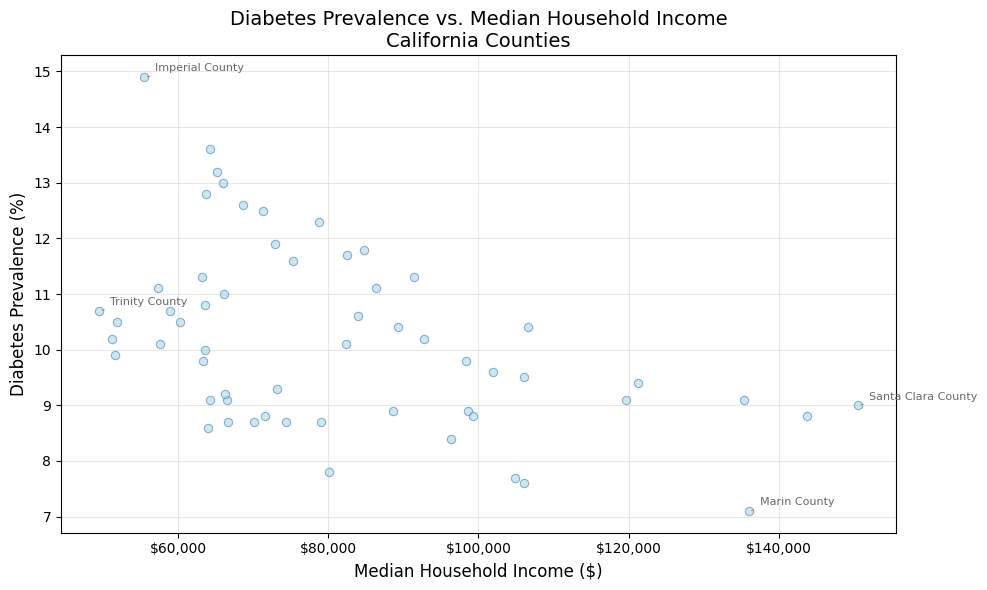

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x_vals = state_data[INCOME_COL]
y_vals = state_data[DIABETES_COL] * 100  # Convert proportion to percentage
counties = state_data["county"]

ax.scatter(
    x_vals,
    y_vals,
    alpha=0.6,
    edgecolors="steelblue",
    facecolors="lightblue",
    linewidths=0.8,
)

# Label a few notable counties so the data feels real.
# We pick the extremes: highest/lowest diabetes, highest/lowest income,
# and any interesting outliers.
label_counties = set()
if len(x_vals) > 0:
    label_counties.add(y_vals.idxmax())  # highest diabetes
    label_counties.add(y_vals.idxmin())  # lowest diabetes
    label_counties.add(x_vals.idxmax())  # highest income
    label_counties.add(x_vals.idxmin())  # lowest income

for idx in label_counties:
    ax.annotate(
        counties.loc[idx],
        (x_vals.loc[idx], y_vals.loc[idx]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8,
        color="dimgray",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    )

ax.set_xlabel("Median Household Income ($)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title(
    f"Diabetes Prevalence vs. Median Household Income\n"
    f"California Counties",
    fontsize=14,
)

# Format the x-axis labels as dollar amounts.
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What Do You See?

If your environment is set up correctly, you should see a scatter plot with a clear
downward trend: counties with higher household incomes tend to have lower diabetes
rates. Look at the labeled counties — the gap between the wealthiest and poorest
counties is striking. This negative relationship is a pattern that public health
researchers have documented extensively — income is one of the strongest social
determinants of health.

But notice that the dots don't fall on a perfect line. Some counties sit well above
or below where the overall trend would place them. What's going on in those places?
Are there other factors — obesity rates, smoking, access to care — that explain the
difference? In the sections that follow, we'll learn how to quantify this relationship
using regression, measure how well our model fits, and ultimately answer the question
we started with: which counties need the most help?

### Workbench Check

If you made it this far without errors, your environment is ready. Here's what we confirmed:

1. **pandas** can load data from a local CSV file
2. **matplotlib** can render charts in your notebook
3. **scikit-learn** is installed (we'll use it starting in Section 3.3)
4. You can load and filter the County Health Rankings dataset

In the next section, we'll dig deeper into this same dataset to understand how
statisticians describe and summarize population health data.

---

## 3.2 Understanding the Data: What Does a Typical County Look Like?

Before fitting any model, we need to understand the shape and character of our data.
In this section we'll compute summary statistics and plot distributions for several
health indicators across California's counties. We'll also build a correlation matrix
to see which indicators tend to move together — a first step toward understanding which
factors might be useful predictors.

The additional columns we'll work with are:

| Column | Description |
|--------|-------------|
| `v009_rawvalue` | Adult smoking rate (proportion of adults who currently smoke) |
| `v011_rawvalue` | Adult obesity rate (proportion of adults with BMI ≥ 30) |
| `v005_rawvalue` | Preventable hospital stays (rate per 100,000 Medicare enrollees) |

In [ ]:
# Define the health indicators we'll study in this section.
INDICATORS = {
    "v060_rawvalue": "Diabetes Prevalence",
    "v009_rawvalue": "Adult Smoking Rate",
    "v011_rawvalue": "Adult Obesity Rate",
    "v005_rawvalue": "Preventable Hospital Stays",
    "v063_rawvalue": "Median Household Income",
}

# Verify all columns are present.
for col, label in INDICATORS.items():
    if col in chr_data.columns:
        print(f"  ✓  '{col}'  ({label})")
    else:
        print(f"  ✗  '{col}'  ({label}) — NOT found")

### Summary Statistics

We'll start with the simplest question: what does a "typical" California county look
like for each of these measures? The pandas `describe()` method gives us the mean,
standard deviation, min, max, and quartiles in one shot.

In [ ]:
# Build a clean dataframe of California county indicators.
ca_indicators = (
    state_data[list(INDICATORS.keys())]
    .rename(columns=INDICATORS)
    .copy()
)

# Scale proportion columns to percentages for readability.
# Preventable hospital stays is already a rate per 100,000, so leave it as-is.
# Median household income is in dollars, so leave it as-is.
pct_cols = ["Diabetes Prevalence", "Adult Smoking Rate", "Adult Obesity Rate"]
ca_indicators[pct_cols] = ca_indicators[pct_cols] * 100

ca_indicators.describe().round(2)

Look at the difference between the mean and the median (the 50th percentile) for each
variable. When those two values are close together, the distribution is roughly symmetric.
When they're far apart, the distribution is skewed — pulled in one direction by extreme
values. We can see this much more clearly with histograms.

### [BONUS] Distributions: Histograms

A histogram bins the data into ranges and counts how many counties fall into each bin.
The shape of the histogram tells us about the distribution. A bell-shaped histogram
indicates a roughly normal (Gaussian) distribution. A histogram with a long tail on
one side indicates a skewed distribution.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Distribution of Health Indicators — California Counties", fontsize=14)

plot_cols = ["Diabetes Prevalence", "Adult Smoking Rate",
             "Adult Obesity Rate", "Preventable Hospital Stays"]
colors = ["steelblue", "seagreen", "coral", "mediumpurple"]

for ax, col, color in zip(axes.flat, plot_cols, colors):
    data = ca_indicators[col].dropna()
    ax.hist(data, bins=15, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="red", linestyle="-", linewidth=1.2,
               label=f"Median: {data.median():.1f}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Counties")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Notice which distributions look roughly symmetric (bell-shaped) and which are skewed.
The dashed black line (mean) and solid red line (median) help you see the skew: when
the mean is pulled to the right of the median, the distribution has a right skew,
meaning a few counties with very high values are pulling the average up.

Understanding the shape of your data matters because many statistical techniques —
including ordinary linear regression — make assumptions about how the data is distributed.
When those assumptions are violated, the results can be misleading.

### Correlation: Which Indicators Move Together?

Correlation measures the strength and direction of a linear relationship between two
variables. A correlation of +1 means they move perfectly together, -1 means they move
in exactly opposite directions, and 0 means no linear relationship.

Let's compute the correlation matrix for all of our California county indicators.

In [ ]:
# Compute the correlation matrix.
corr_matrix = ca_indicators.corr().round(3)

# Display it as a heatmap.
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

# Label the axes.
labels = corr_matrix.columns
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

# Annotate each cell with the correlation value.
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=10,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Correlation", shrink=0.8)
ax.set_title("Correlation Between Health Indicators — California Counties", fontsize=13)
plt.tight_layout()
plt.show()

Take a moment to study the heatmap. The strong positive correlations between diabetes,
smoking, and obesity probably aren't surprising — counties where one is high tend to have
the others high as well. And the negative correlation with income is consistent with the
scatter plot we created in section 3.1.

But look more closely at preventable hospital stays. Its correlations with the other health
behaviors may be weaker than you'd expect. That's because it captures something different:
not just how sick a population is, but how well the local healthcare system manages chronic
conditions. A county with high obesity but good primary care might still have low
preventable hospitalization rates. This is a hint that our predictors are measuring
overlapping but distinct aspects of community health — something that will matter when
we combine them into a multiple regression model in section 3.4.

---

## 3.3 Linear Regression: Drawing the Line

Let's return to the scatter plot of diabetes prevalence vs. median household income for
California counties. There's clearly a downward trend — but can we quantify it? Can we
draw the "best" line through the data and use it to make predictions?

Linear regression gives us a way to do exactly that. The model takes the form:

$$y = mx + b$$

where *y* is the outcome we want to predict (diabetes prevalence), *x* is the predictor
(household income), *m* is the slope (how much *y* changes when *x* increases by one unit),
and *b* is the intercept (the predicted *y* when *x* is zero).

But what makes a line "best"? We need a way to measure how wrong a line is. The standard
approach is **mean squared error (MSE)**: for each county, compute the gap between the
actual value and the predicted value (the **residual**), square it, and take the average
across all counties. The best line is the one that minimizes this number.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

OBESITY_COL = "v011_rawvalue"

# Prepare the data. scikit-learn expects X as a 2D array.
X = state_data[[OBESITY_COL]].values * 100 # percentage
y = state_data[DIABETES_COL].values * 100  # percentage

# Fit a simple linear regression.
model_simple = LinearRegression()
model_simple.fit(X, y)

# Predictions for the regression line.
y_pred = model_simple.predict(X)

# Metrics.
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Slope (m):     {model_simple.coef_[0]:.6f}")
print(f"Intercept (b): {model_simple.intercept_:.2f}")
print(f"MSE:           {mse:.4f}")
print(f"R²:            {r2:.4f}")

What do these numbers mean?

- The **slope** tells you how much diabetes prevalence changes for each dollar increase
  in median household income. A negative slope confirms the downward trend.
- The **intercept** is the model's prediction when income is zero — not meaningful in
  practice, but needed to position the line.
- **MSE** measures the average squared error. Lower is better.
- **R²** tells you the fraction of the variation in diabetes prevalence that the model
  explains. A value of 1.0 would mean a perfect fit; 0.0 means the model explains nothing.

Let's plot the regression line on top of the scatter plot to see how it looks.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of actual data.
ax.scatter(X, y, alpha=0.6, edgecolors="steelblue", facecolors="lightblue",
           linewidths=0.8, label="Actual")

# Regression line.
income_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax.plot(income_range, model_simple.predict(income_range),
        color="red", linewidth=2, label=f"Regression line (R²={r2:.3f})")

ax.set_xlabel("Adult Obesity Rate (%)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Linear Regression: Diabetes Prevalence vs. Obesity\nCalifornia Counties",
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### [BONUS] Residuals: What the Model Misses

The vertical distance between each dot and the regression line is the **residual** — the
error for that county. Plotting the residuals helps us see patterns the model is missing.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

residuals = y - y_pred
ax.scatter(y_pred, residuals, alpha=0.6, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8)
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Predicted Diabetes Prevalence (%)", fontsize=12)
ax.set_ylabel("Residual (Actual − Predicted)", fontsize=12)
ax.set_title("Residual Plot — Simple Linear Regression", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

If the linear model were a perfect fit, the residuals would be randomly scattered around
the zero line with no visible pattern. Any pattern in the residuals — a curve, a funnel
shape, clusters — tells us the model is missing something.

**Key bridge to neural networks:** This idea of "measure how wrong you are, then adjust"
is the fundamental principle behind how neural networks learn. A single linear regression
is, in a very real sense, a one-neuron neural network with no activation function. We'll
build on this idea throughout the chapter.

### Using the Model to Make Predictions

So far, we've fit our model using *all* the data and measured how well it fits that same
data. But the real question is: **can the model predict values it hasn't seen before?**

To test this, we split the data into two parts:
- A **training set** that we use to fit the model.
- A **test set** that we hold back and use only for evaluation.

If the model performs well on the test set — data it never saw during training — that's
evidence it has learned a real pattern, not just memorized the training data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split: 70% for training, 30% for testing.
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Training counties: {len(X_train_s)}")
print(f"Test counties:     {len(X_test_s)}")

# Fit the model on ONLY the training data.
model_split = LinearRegression()
model_split.fit(X_train_s, y_train_s)

# Predict on the test set — counties the model has never seen.
y_test_pred = model_split.predict(X_test_s)

r2_train_s = model_split.score(X_train_s, y_train_s)
r2_test_s = model_split.score(X_test_s, y_test_s)
mse_test_s = mean_squared_error(y_test_s, y_test_pred)

print(f"\nR² on training data: {r2_train_s:.4f}")
print(f"R² on test data:     {r2_test_s:.4f}")
print(f"MSE on test data:    {mse_test_s:.4f}")

In [ ]:
# Visualize: training data, test data, and the regression line.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_train_s, y_train_s, alpha=0.6, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Training data")
ax.scatter(X_test_s, y_test_s, alpha=0.8, edgecolors="coral",
           facecolors="lightsalmon", linewidths=0.8, marker="s", s=60,
           label="Test data")

# Draw the regression line (fit on training data only).
income_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax.plot(income_range, model_split.predict(income_range),
        color="red", linewidth=2, label=f"Regression line (test R²={r2_test_s:.3f})")

ax.set_xlabel("Adult Obesity Rate (%)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Train/Test Split: Can the Model Predict Unseen Counties?\nCalifornia",
             fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The square markers show the test counties — data the model never saw during training.
If the regression line runs through them reasonably well, the model has predictive power.
Compare the training R² to the test R²: if they're in the same ballpark, the model
is generalizing rather than memorizing. We'll explore this idea more formally in section
3.7.

---

## 3.4 Multiple Regression: Health Is Never Just One Thing

Diabetes isn't driven by income alone. The correlation matrix in section 3.2 showed that
smoking, obesity, and other factors also correlate with diabetes prevalence. Multiple
regression lets us include all of these predictors at once. The model becomes:

$$y = w_1 x_1 + w_2 x_2 + w_3 x_3 + \cdots + b$$

Each predictor gets its own coefficient (or **weight**), and the model combines them into
a single prediction. Each weight tells us how much the outcome changes when that predictor
increases by one unit, *holding all other predictors constant*.

**Key bridge to neural networks:** This is directly analogous to how a single neuron
combines multiple weighted inputs. The jump from multiple regression to a neural network
is smaller than you might think.

In [ ]:
# Predictors: income, obesity, smoking, and preventable hospital stays.
PREDICTORS = {
    "v063_rawvalue": "Median Household Income",
    "v011_rawvalue": "Adult Obesity Rate",
    "v009_rawvalue": "Adult Smoking Rate",
    "v005_rawvalue": "Preventable Hospital Stays",
}

# Build a clean dataframe for California, dropping rows with any missing predictor.
multi_data = state_data[["county"] + list(PREDICTORS.keys()) + [DIABETES_COL]].dropna().copy()

X_multi = multi_data[list(PREDICTORS.keys())].values
y_multi = multi_data[DIABETES_COL].values * 100  # percentage

# Fit a multiple regression.
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y_multi, y_pred_multi)
mse_multi = mean_squared_error(y_multi, y_pred_multi)

print("Multiple Regression Results")
print("=" * 50)
for name, coef in zip(PREDICTORS.values(), model_multi.coef_):
    print(f"  {name:30s}  weight = {coef:+.6f}")
print(f"  {'Intercept':30s}  bias   = {model_multi.intercept_:+.4f}")
print(f"\n  MSE: {mse_multi:.4f}")
print(f"  R²:  {r2_multi:.4f}")
print(f"\nCompare to simple regression R²: {r2:.4f}")

The R² value should be higher than our simple regression, meaning the model explains
more of the variation in diabetes prevalence when it accounts for multiple factors.

Look at the weights. The obesity rate should have the largest positive coefficient — it
is the single strongest predictor of county-level diabetes prevalence across California.
Income's weight is negative, confirming what we saw in section 3.1: wealthier counties
have lower diabetes rates. You might notice that smoking's weight is smaller than you'd
expect given its correlation with diabetes in the heatmap. That's because smoking and
obesity are themselves correlated — when both are in the model, they share credit for
the variation they explain, and obesity takes the larger share.

This lines up with what public health researchers call the **social determinants of
health**: the conditions in which people live, work, and age shape their health outcomes
in powerful, measurable ways. The model quantifies what we suspected: health is never
just one thing, and the factors that drive diabetes in a community are tangled together.

In [ ]:
# Visualize: actual vs. predicted for the multiple regression model.
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_multi, y_pred_multi, alpha=0.6, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8)

# Perfect-prediction line.
lims = [min(y_multi.min(), y_pred_multi.min()) - 0.5,
        max(y_multi.max(), y_pred_multi.max()) + 0.5]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")

ax.set_xlabel("Actual Diabetes Prevalence (%)", fontsize=12)
ax.set_ylabel("Predicted Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Multiple Regression: Actual vs. Predicted\nCalifornia Counties",
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

Points that fall close to the red dashed line are counties where the model's prediction
is very accurate. Points far from the line are counties where other unmeasured factors
are influencing diabetes prevalence. No model captures everything — but multiple
regression gives us a much richer picture than a single predictor alone.

---

## 3.5 When Lines Aren't Enough: Polynomial Regression

So far, all of our models have been linear — they draw straight lines (or flat planes)
through the data. But many real-world relationships curve. Let's go back to our California
county data and look at the relationship between preventable hospital stays and diabetes
prevalence.

In section 3.3 we saw that obesity and diabetes have a roughly linear relationship — a
straight line captures the trend reasonably well. But think about what preventable hospital
stays really measure. At low levels, a county's healthcare system is doing a good job
managing chronic conditions — patients get routine checkups, medications are adjusted, and
hospitalizations are avoided. But as preventable stays climb, something different may be
happening. The relationship between avoidable hospitalizations and diabetes prevalence
may not be a straight line — it may curve, reflecting a threshold effect where healthcare
system strain begins to compound.

Let's see if the data supports that intuition.

In [6]:
# Prepare the data: preventable hospital stays vs. diabetes prevalence.
HOSP_COL = "v005_rawvalue"

poly_data = state_data[[DIABETES_COL, HOSP_COL]].dropna().copy()
poly_data.columns = ["diabetes", "hosp_stays"]

# Convert diabetes from proportion to percentage for readability.
poly_data["diabetes_pct"] = poly_data["diabetes"] * 100

print(f"Counties with complete data: {len(poly_data)}")
print(f"Preventable stays range: {poly_data['hosp_stays'].min():,.0f} to {poly_data['hosp_stays'].max():,.0f} per 100K")
print(f"Diabetes range: {poly_data['diabetes_pct'].min():.1f}% to {poly_data['diabetes_pct'].max():.1f}%")

Counties with complete data: 58
Preventable stays range: 921 to 3,939 per 100K
Diabetes range: 7.1% to 14.9%


### Visualizing the Relationship

Let's plot preventable hospital stays against diabetes prevalence and see whether a
straight line looks like the right tool.

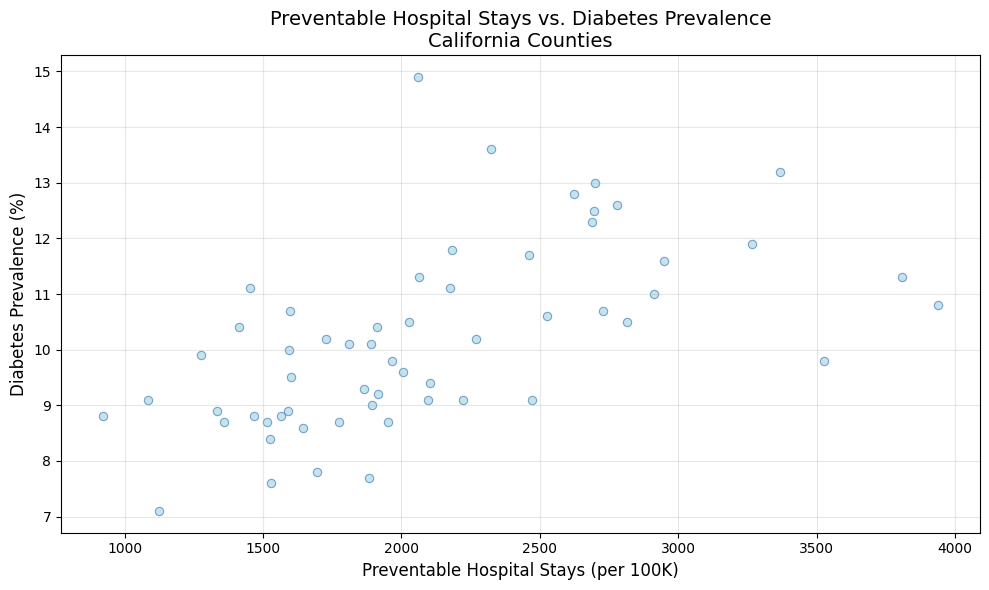

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(poly_data["hosp_stays"], poly_data["diabetes_pct"],
           alpha=0.7, edgecolors="steelblue", facecolors="lightblue", linewidths=0.8)
ax.set_xlabel("Preventable Hospital Stays (per 100K)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Preventable Hospital Stays vs. Diabetes Prevalence\nCalifornia Counties",
             fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Look at the shape of the scatter. If the relationship were purely linear, the dots would
cluster around an imaginary straight line. Instead, the data appears to curve — diabetes
prevalence rises slowly at the low end of preventable stays but steepens as preventable
hospitalizations climb higher. A straight line would systematically overpredict in the
middle and underpredict at the extremes.

### Fitting Polynomial Models

Polynomial regression extends linear regression by adding powers of the predictor.
Instead of $y = mx + b$, we fit $y = ax^2 + bx + c$ (quadratic), or
$y = ax^3 + bx^2 + cx + d$ (cubic), and so on.

NameError: name 'LinearRegression' is not defined

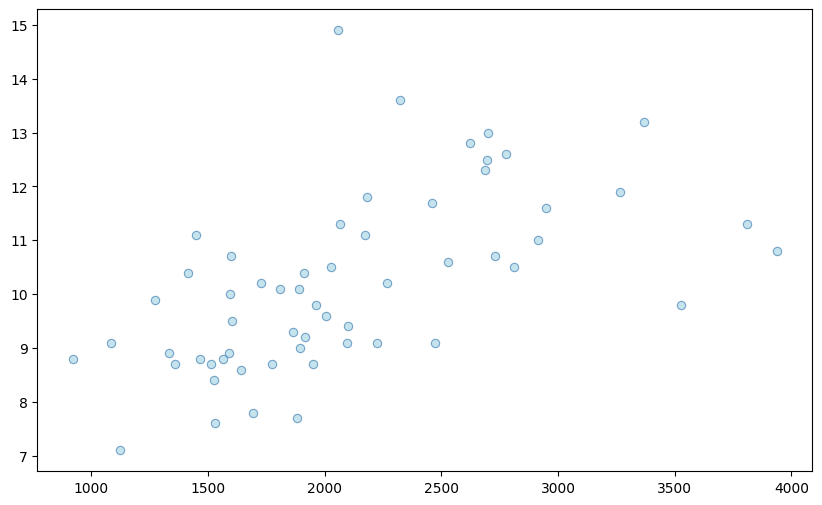

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X_poly = poly_data[["hosp_stays"]].values
y_poly = poly_data["diabetes_pct"].values

# Fit models of increasing complexity.
degrees = [1, 2, 3]
models_poly = {}
colors_poly = ["gray", "orange", "red"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_poly, y_poly, alpha=0.7, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Actual", zorder=5)

x_smooth = np.linspace(X_poly.min(), X_poly.max(), 200).reshape(-1, 1)

for deg, color in zip(degrees, colors_poly):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_poly, y_poly)
    y_hat = pipe.predict(x_smooth)
    r2 = pipe.score(X_poly, y_poly)
    models_poly[deg] = pipe
    label = f"Degree {deg} (R²={r2:.3f})"
    ax.plot(x_smooth, y_hat, color=color, linewidth=2, label=label)

ax.set_xlabel("Preventable Hospital Stays (per 100K)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Polynomial Regression: Preventable Stays vs. Diabetes", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### The Danger of Overfitting

A higher-degree polynomial can wiggle through the data more closely — but that isn't
always a good thing. With only 58 counties (far fewer data points than we had in earlier
sections), a high-degree polynomial can start chasing individual counties rather than
learning the real underlying pattern. Let's see what happens.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_poly, y_poly, alpha=0.7, edgecolors="steelblue",
           facecolors="lightblue", linewidths=0.8, label="Actual", zorder=5)

for deg, color, ls in [(3, "red", "-"), (10, "purple", "--"), (20, "green", ":")]:
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_poly, y_poly)
    y_hat = pipe.predict(x_smooth)
    r2 = pipe.score(X_poly, y_poly)
    ax.plot(x_smooth, y_hat, color=color, linewidth=2, linestyle=ls,
            label=f"Degree {deg} (R²={r2:.3f})")

ax.set_xlabel("Preventable Hospital Stays (per 100K)", fontsize=12)
ax.set_ylabel("Diabetes Prevalence (%)", fontsize=12)
ax.set_title("Overfitting: High-Degree Polynomials Chase Noise", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice how the high-degree polynomials (dashed and dotted lines) swing wildly, especially
at the edges of the data range. The degree-20 polynomial might even dip below zero —
predicting *negative* diabetes prevalence, which is nonsensical. These models achieve
a higher R² on the training data by memorizing the position of individual counties rather
than learning the real underlying pattern. This is **overfitting** — the model fits the
training data so closely that it would give terrible predictions on new data.

This problem is especially acute with small datasets. We have only 58 California counties,
so a degree-20 polynomial has almost as many parameters as data points. There's nothing
left for the model to generalize from — it just memorizes.

**Key bridge to neural networks:** Neural networks solve the non-linearity problem using
**activation functions** rather than polynomial terms. The key insight is the same: real-world
relationships are rarely straight lines, so we need tools that can bend. But we also need
to guard against bending too much.

### Predicting Diabetes Prevalence for Unseen Counties

Let's make the overfitting problem concrete by splitting the data into training and test
sets. We'll fit polynomials of different degrees on the training counties and see how
well they **predict** diabetes prevalence for the held-out test counties — counties the
model has never seen.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=42
)
print(f"Training counties: {len(X_train_p)}")
print(f"Test counties:     {len(X_test_p)}")

# Fit polynomial models of increasing degree on training data only.
# Evaluate on both training and test data.
print(f"\n{'Degree':<8} {'Train R²':<12} {'Test R²':<12} {'Test MSE':>12}")
print("-" * 46)
poly_results = []
for deg in [1, 2, 3, 5, 10]:
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_train_p, y_train_p)
    r2_tr = pipe.score(X_train_p, y_train_p)
    r2_te = pipe.score(X_test_p, y_test_p)
    mse_te = mean_squared_error(y_test_p, pipe.predict(X_test_p))
    poly_results.append({"deg": deg, "r2_tr": r2_tr, "r2_te": r2_te})
    print(f"{deg:<8} {r2_tr:<12.4f} {r2_te:<12.4f} {mse_te:>12,.0f}")

In [ ]:
# Visualize: training R² vs test R² as polynomial degree increases.
fig, ax = plt.subplots(figsize=(9, 6))
degs = [r["deg"] for r in poly_results]
ax.plot(degs, [r["r2_tr"] for r in poly_results],
        "o-", color="steelblue", linewidth=2, markersize=8, label="Training R²")
ax.plot(degs, [r["r2_te"] for r in poly_results],
        "s--", color="coral", linewidth=2, markersize=8, label="Test R²")

ax.set_xlabel("Polynomial Degree", fontsize=12)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Prediction Accuracy: Training vs. Test Data\nPreventable Stays vs. Diabetes Prevalence",
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(degs)
plt.tight_layout()
plt.show()

This chart makes the overfitting problem unmistakable. As the polynomial degree
increases, the training R² keeps climbing — but the test R² peaks and then drops. The
high-degree polynomials are memorizing quirks of the training counties rather than learning
the real relationship between diabetes and preventable hospitalizations. When asked to
predict outcomes for counties they haven't seen, they perform *worse* than a simpler model.

With only ~40 training counties, even modest complexity can overfit. This is the core
lesson: **a model's value lies in its ability to predict, not in how well it fits the
data it was trained on.** We'll return to this principle in section 3.7.

---

## 3.6 How Models Learn: Teaching a Computer to Get Better Over Time

So far, we've been using scikit-learn to fit our models with a single call to `.fit()`.
But how does the fitting actually work under the hood? The answer is an algorithm called
**gradient descent**.

> **Gradient descent** is an iterative optimization algorithm that finds the parameter
> values (slope and intercept in a linear model, or weights in a neural network) that
> minimize a loss function. It works by repeatedly measuring the current error, calculating
> which direction to adjust the parameters to reduce that error, and taking a small step
> in that direction — much like descending a hill by always stepping downward.

In this section, we'll implement gradient descent from scratch using nothing but Python
and NumPy. We'll go back to our California data — predicting diabetes prevalence from
median household income — but this time we'll watch the model learn step by step rather
than letting scikit-learn do it invisibly.

### The Idea

Gradient descent works like this:

1. **Start with a guess.** Pick random values for the slope and intercept.
2. **Measure how wrong you are.** Compute the mean squared error.
3. **Figure out which direction to adjust.** Compute the *gradient* — how the error changes
   when you nudge each parameter. The gradient points uphill, so we move in the opposite
   direction.
4. **Take a small step in the right direction.** Adjust the slope and intercept to reduce
   the error.
5. **Repeat** until the error stops decreasing.

**Key bridge to neural networks:** This is exactly the same algorithm that trains neural
networks. The only difference is scale — a simple regression has 2 parameters; a large
neural network has millions. The principle is identical.

In [ ]:
# We'll work with the California data from section 3.1.
# Normalize the features so gradient descent converges nicely.
X_gd = state_data[OBESITY_COL].values * 100 # percentage
y_gd = state_data[DIABETES_COL].values * 100  # percentage

# Feature scaling: subtract mean, divide by std.
X_mean, X_std = X_gd.mean(), X_gd.std()
y_mean, y_std = y_gd.mean(), y_gd.std()
X_norm = (X_gd - X_mean) / X_std
y_norm = (y_gd - y_mean) / y_std

# Initialize parameters randomly.
np.random.seed(42)
m = np.random.randn()  # slope
b = np.random.randn()  # intercept

# Hyperparameters.
learning_rate = 0.1
n_iterations = 50
n = len(X_norm)

# Track the history for visualization.
history = {"iteration": [], "m": [], "b": [], "mse": []}

for i in range(n_iterations):
    # Forward pass: make predictions.
    y_hat = m * X_norm + b

    # Compute loss (MSE).
    error = y_hat - y_norm
    mse = (error ** 2).mean()

    # Compute gradients.
    dm = (2 / n) * (error * X_norm).sum()
    db = (2 / n) * error.sum()

    # Update parameters.
    m -= learning_rate * dm
    b -= learning_rate * db

    # Record history.
    history["iteration"].append(i)
    history["m"].append(m)
    history["b"].append(b)
    history["mse"].append(mse)

print(f"Final MSE (normalized): {history['mse'][-1]:.6f}")
print(f"Converged after {n_iterations} iterations")

### Watching the Model Learn

Let's plot the regression line at several points during training to see how it evolves
from a random guess toward the best fit.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
snapshots = [0, 5, n_iterations - 1]

for ax, idx in zip(axes, snapshots):
    ax.scatter(X_norm, y_norm, alpha=0.5, edgecolors="steelblue",
               facecolors="lightblue", linewidths=0.6, s=30)

    m_snap = history["m"][idx]
    b_snap = history["b"][idx]
    x_line = np.array([X_norm.min(), X_norm.max()])
    ax.plot(x_line, m_snap * x_line + b_snap, "r-", linewidth=2)

    ax.set_title(f"Iteration {idx}\nMSE = {history['mse'][idx]:.4f}", fontsize=12)
    ax.set_xlabel("Obesity (normalized)")
    ax.set_ylabel("Diabetes Prevalence (normalized)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Gradient Descent: Watching the Model Learn", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### The Loss Landscape

We can also visualize the loss as a function of the slope and intercept. Gradient descent
walks downhill on this surface toward the minimum.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["iteration"], history["mse"], "o-", color="steelblue",
        markersize=4, linewidth=1.5)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Mean Squared Error", fontsize=12)
ax.set_title("Loss Curve: MSE Over Training Iterations", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparing to scikit-learn

Let's confirm that our hand-built gradient descent arrived at the same answer as
scikit-learn's closed-form solution.

In [ ]:
# Convert our normalized parameters back to the original scale.
m_original = m * (y_std / X_std)
b_original = y_mean + b * y_std - m_original * X_mean

print("Gradient Descent (our implementation):")
print(f"  Slope:     {m_original:.6f}")
print(f"  Intercept: {b_original:.4f}")
print()
print("scikit-learn (closed-form solution):")
print(f"  Slope:     {model_simple.coef_[0]:.6f}")
print(f"  Intercept: {model_simple.intercept_:.4f}")
print()
diff_m = abs(m_original - model_simple.coef_[0])
diff_b = abs(b_original - model_simple.intercept_)
print(f"Difference in slope:     {diff_m:.8f}")
print(f"Difference in intercept: {diff_b:.8f}")

The values should be very close (though not perfectly identical, since gradient descent
is an iterative approximation while scikit-learn uses an exact algebraic solution). The
small remaining difference could be reduced further by running more iterations or using
a smaller learning rate.

The important takeaway: you've now seen the same algorithm that powers modern neural
network training, just applied to two parameters instead of millions.

---

## 3.7 Knowing What You Don't Know: Measuring Model Quality

A model that fits the training data well isn't necessarily a good model. We saw this with
polynomial regression in section 3.5 — a high-degree polynomial can achieve a near-perfect
R² on the training data while giving wild predictions on new data.

In this section, we'll learn the standard techniques for honestly evaluating model quality:
train/test splits, cross-validation, and the bias-variance tradeoff. We'll apply them to
our California county data from section 3.4.

### Train/Test Split

The simplest approach: hold out some of the data for testing. Train the model on one
portion, then evaluate it on data it has never seen.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score

# Use the same multiple regression setup from section 3.4.
X_eval = multi_data[list(PREDICTORS.keys())].values
y_eval = multi_data[DIABETES_COL].values * 100

# Split: 70% training, 30% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X_eval, y_eval, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} counties")
print(f"Test set:     {len(X_test)} counties")

# Fit on training data only.
model_eval = LinearRegression()
model_eval.fit(X_train, y_train)

# Evaluate on both sets.
r2_train = model_eval.score(X_train, y_train)
r2_test = model_eval.score(X_test, y_test)

print(f"\nR² on training data: {r2_train:.4f}")
print(f"R² on test data:     {r2_test:.4f}")

If the model is working well, the training and test R² values should be in the same
ballpark. A big gap — high training R², low test R² — is a sign of overfitting.

With only 58 California counties and a 70/30 split, the test set is small (~17 counties),
so the estimate can be noisy. Cross-validation gives us a more stable picture.

### Cross-Validation

Instead of a single split, cross-validation divides the data into *k* equal parts (folds).
It trains the model *k* times, each time holding out a different fold for testing and
training on the rest. The result is *k* different R² scores, whose average gives a more
reliable estimate of model quality.

In [ ]:
# 5-fold cross-validation on the full California dataset.
cv_scores = cross_val_score(LinearRegression(), X_eval, y_eval, cv=5, scoring="r2")

print("Cross-validation R² scores (5 folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean R²:  {cv_scores.mean():.4f}")
print(f"Std dev:  {cv_scores.std():.4f}")

The mean cross-validation R² is a more honest estimate of how well the model would
perform on new California counties. The standard deviation tells you how much the
performance varies depending on which counties end up in the test fold.

### The Bias-Variance Tradeoff

This is one of the most important concepts in all of statistics and machine learning.
Let's see it in action by comparing models of different complexity on the same data.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# We'll use diabetes prevalence vs. income (single predictor) to make
# the comparison easy to visualize.
X_bv = state_data[[OBESITY_COL]].values * 100
y_bv = state_data[DIABETES_COL].values * 100

degrees_to_test = [1, 2, 3, 5, 10]
results = []

for deg in degrees_to_test:
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())

    # Train on all data (for training R²).
    pipe.fit(X_bv, y_bv)
    r2_all = pipe.score(X_bv, y_bv)

    # Cross-validated R² (honest estimate).
    cv = cross_val_score(pipe, X_bv, y_bv, cv=5, scoring="r2")

    results.append({
        "Degree": deg,
        "Training R²": round(r2_all, 4),
        "CV Mean R²": round(cv.mean(), 4),
        "CV Std": round(cv.std(), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

In [ ]:
# Visualize the bias-variance tradeoff.
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(results_df["Degree"], results_df["Training R²"],
        "o-", color="steelblue", linewidth=2, markersize=8, label="Training R²")
ax.plot(results_df["Degree"], results_df["CV Mean R²"],
        "s--", color="coral", linewidth=2, markersize=8, label="Cross-Validation R²")

ax.set_xlabel("Polynomial Degree (Model Complexity)", fontsize=12)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("The Bias-Variance Tradeoff\nDiabetes Prevalence vs. Obesity — California Counties",
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees_to_test)
plt.tight_layout()
plt.show()

As model complexity increases (higher polynomial degree):

- **Training R² goes up** — the model memorizes the training data more closely.
- **Cross-validation R² may go up at first, then drops** — beyond a point, the model
  starts fitting noise rather than real patterns.

The sweet spot is where cross-validation R² is highest. A model that is too simple
(**high bias**) underfits — it can't capture the real pattern. A model that is too
complex (**high variance**) overfits — it captures noise that won't generalize.

**Key bridge to neural networks:** These same evaluation techniques — train/test splits,
cross-validation, watching for overfitting — are used identically in deep learning. The
reader is building habits they'll use throughout the book.

---

## 3.8 Putting It Together: Not Everything Needs AI

Let's return to the scenario we set up at the beginning of this chapter. You work at
the California Department of Health and your director has asked two questions:

1. *"Which counties should we prioritize for diabetes prevention programs?"*
2. *"If a county improves its obesity rate or income levels, how much can we expect
   diabetes prevalence to change?"*

Both are prediction problems — the first asks the model to identify outliers, the second
asks it to forecast the effect of a potential intervention. With the tools from this
chapter, you can build practical, interpretable answers without any neural networks or
AI.

### Identifying Priority Counties

We'll use our multiple regression model to predict each county's diabetes prevalence
based on its social and health indicators. Counties where the actual rate is much higher
than predicted may have unmeasured factors driving up diabetes — these are candidates
for deeper investigation and targeted intervention.

In [ ]:
# Refit the multiple regression on all California counties.
model_final = LinearRegression()
model_final.fit(X_multi, y_multi)
predicted = model_final.predict(X_multi)
residuals_final = y_multi - predicted

# Build a summary table.
summary = multi_data[["county"]].copy()
summary.columns = ["County"]
summary["Actual Diabetes (%)"] = y_multi.round(2)
summary["Predicted Diabetes (%)"] = predicted.round(2)
summary["Residual (%)"] = residuals_final.round(2)
summary = summary.sort_values("Residual (%)", ascending=False).reset_index(drop=True)

print("Counties where diabetes is HIGHER than the model predicts")
print("(positive residual = potential priority for intervention)")
print("=" * 65)
print(summary.head(10).to_string(index=False))
print()
print("\nCounties where diabetes is LOWER than the model predicts")
print("(negative residual = potential bright spots to learn from)")
print("=" * 65)
print(summary.tail(10).to_string(index=False))

In [ ]:
# Visualize the residuals on a bar chart.
fig, ax = plt.subplots(figsize=(14, 6))

colors = ["coral" if r > 0 else "steelblue" for r in summary["Residual (%)"]]
ax.barh(range(len(summary)), summary["Residual (%)"], color=colors, edgecolor="white")
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary["County"], fontsize=8)
ax.set_xlabel("Residual: Actual − Predicted Diabetes Prevalence (%)", fontsize=12)
ax.set_title(
    "California Counties: Diabetes Prevalence vs. Model Prediction\n"
    "Coral = higher than expected | Blue = lower than expected",
    fontsize=13,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Look at the counties at the top of the chart — those with the largest positive residuals.
These are places where diabetes prevalence is substantially higher than what their income,
obesity, smoking, and hospitalization rates would predict. Something else is going on in
these communities that our model doesn't capture: perhaps limited access to healthy food,
fewer healthcare providers, cultural factors, or environmental exposures. These are
exactly the counties a health department would want to investigate further — not because
they have the highest diabetes rates in absolute terms, but because their rates are higher
than their demographics alone would explain.

Now look at the bottom of the chart — the counties with large negative residuals. These
are performing *better* than expected. Whatever they're doing — community health programs,
better access to preventive care, local policies — is working. A smart health department
wouldn't just target the struggling counties; it would also study the bright spots to
understand what can be replicated elsewhere.

This is the kind of actionable intelligence you can extract from a straightforward
regression model — no neural network required.

### What-If Predictions: Simulating an Intervention

Regression models don't just describe the past — they can help us reason about the future.
Suppose the California Department of Health is considering an obesity-reduction program
and wants to estimate how much diabetes prevalence might decrease if a county's obesity
rate dropped by 5 percentage points.

We can answer this by taking the actual data for each county, adjusting the obesity rate
downward, and asking the model to predict the new diabetes prevalence. The difference
between the original prediction and the adjusted prediction is the model's estimate of
the intervention's effect.

> **Important caveat:** Regression models identify *associations*, not necessarily
> *causation*. The model tells us that counties with lower obesity tend to have lower
> diabetes, but it doesn't prove that reducing obesity will directly cause diabetes to
> drop by exactly this amount. Still, these estimates are a valuable starting point for
> planning and prioritization.

In [ ]:
# Simulate a 5-percentage-point reduction in obesity for each county.
# The obesity column is the 2nd predictor (index 1) in our PREDICTORS dictionary.
predictor_names = list(PREDICTORS.keys())
obesity_idx = predictor_names.index("v011_rawvalue")

X_whatif = X_multi.copy()
X_whatif[:, obesity_idx] = X_whatif[:, obesity_idx] - 0.05  # subtract 5 percentage points

predicted_original = model_final.predict(X_multi)
predicted_whatif = model_final.predict(X_whatif)
predicted_change = predicted_whatif - predicted_original

print("Predicted effect of a 5-percentage-point reduction in obesity rate:")
print(f"  Average change in diabetes prevalence: {predicted_change.mean():.2f} percentage points")
print(f"  Range: {predicted_change.min():.2f} to {predicted_change.max():.2f} percentage points")
print()
print("This is based on the model's coefficient for obesity:")
print(f"  Weight = {model_final.coef_[obesity_idx]:.4f}")
print(f"  So a 0.05 change in obesity → {model_final.coef_[obesity_idx] * 0.05:.2f} change in diabetes %")

There's your answer for the director: the model estimates that a program reducing obesity
by 5 percentage points could lower diabetes prevalence by a meaningful amount across
California counties. That's a concrete, defensible number to put in a budget proposal.

Because this is a linear model, the predicted change is uniform across counties — it's
the obesity weight multiplied by the size of the change. In reality, the impact would
likely vary: a rural county with limited healthcare infrastructure might respond differently
than a suburban county with strong primary care. More complex models — including the neural
networks we'll build in later chapters — can capture those kinds of interactions. But for
a first-pass estimate to support a funding request, this is exactly the kind of analysis
a health department needs.

### When Do You Need AI?

The regression models we built in this chapter are simple, fast, interpretable, and useful.
A public health analyst can explain exactly why the model flagged a particular county or
predicted a particular outcome — it's not a black box. For many population health
questions, this is exactly the right tool.

You might need something more powerful — a neural network, a random forest, or another
machine learning model — when:

- The relationships in your data are highly non-linear and interactions between variables
  are complex (we saw a taste of this with polynomial regression).
- You have very large datasets with hundreds or thousands of features.
- You're working with unstructured data like medical images, clinical notes, or genomic
  sequences.
- The patterns in the data are too subtle for a human to specify in a formula.
- You need predictions that account for complex interactions between variables (e.g., the
  effect of income on diabetes might depend on a county's rural vs. urban character).

In the chapters ahead, we'll encounter exactly these situations and build the tools to
handle them. But the foundation you've built here — loss functions, predictions, gradient
descent, model evaluation, and the bias-variance tradeoff — will carry through everything
that follows.

---

### Chapter 3 Summary

In this chapter, you learned:

1. **Descriptive statistics** — how to summarize and visualize population health data
   using means, medians, histograms, and correlation matrices (Section 3.2).

2. **Linear regression and prediction** — how to model the relationship between a
   predictor and an outcome, how to split data into training and test sets to verify
   that the model can predict values it hasn't seen, and what slope, intercept, MSE,
   and R² mean (Section 3.3).

3. **Multiple regression** — how to include several predictors at once, with each
   getting its own weight — directly analogous to how a neuron combines inputs
   (Section 3.4).

4. **Polynomial regression and overfitting** — how to model non-linear relationships,
   and how train/test evaluation reveals the danger of overfitting when the model is
   too complex (Section 3.5).

5. **Gradient descent** — the algorithm that powers both classical regression and modern
   neural networks: measure the error, compute the gradient, take a step (Section 3.6).

6. **Model evaluation** — cross-validation and the bias-variance tradeoff as tools
   for choosing between models of different complexity (Section 3.7).

7. **Practical prediction** — how to use models to identify outlier counties, simulate
   the effect of interventions, and make evidence-based recommendations (Section 3.8).

Along the way, we made concrete discoveries about California's counties: obesity is the
strongest predictor of county-level diabetes prevalence, some counties have diabetes rates
well above what their demographics would predict (making them candidates for targeted
intervention), and a modest reduction in obesity could produce a meaningful decrease in
diabetes statewide. We answered the director's questions with real data and a model we
can explain in plain language.

A recurring theme across these sections is that **the purpose of a model is to make
predictions about data it hasn't seen before.** A model that memorizes its training data
but fails on new data is useless — a lesson that applies equally to the simple regressions
in this chapter and the deep neural networks we'll build later. In the next chapter, we'll
see how these concepts extend into the world of neural networks.